# The Well · `active_matter` — statistical analysis

This notebook analyzes how **initial / control parameters** (`alpha` = dipole strength, `zeta` = alignment) drive simulation outcomes, validates approximate physics laws, and flags anomalous trajectories.

**Data:** tidy feature table built by `python -m src.extract_features` (synthetic demo by default; stream real HDF5 from Hugging Face when ready).

**Methods:** two-way ANOVA, one-way ANOVA + Tukey, pairwise t-tests, assumption checks, Kruskal–Wallis fallback, physics checks, MAD/IQR anomaly detection.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.stats import (
    assumption_checks,
    detect_anomalies,
    kruskal_wallis,
    one_way_anova,
    pairwise_ttests,
    physics_validation,
    two_way_anova,
)

sns.set_theme(style="whitegrid", context="notebook")
FEATURES = ROOT / "data" / "features.parquet"
df = pd.read_parquet(FEATURES)
print(df.shape)
df.head()

(134, 20)


,split,file,traj_idx,replicate,alpha,zeta,L,mean_concentration,std_concentration,nematic_order_S,nematic_order_S_final,kinetic_energy,enstrophy,div_u_rms,spectral_slope,time_to_steady,n_timesteps_used,spatial_resolution_used,synthetic,injected_anomaly
0,train,active_matter_L_10.0_zeta_1.0_alpha_-1.0.hdf5,0,0,-1.0,1.0,10.0,1.0,0.004135,0.822481,0.945981,0.042034,0.009077,0.181721,-5.400855,0.7,11,16,False,False
1,train,active_matter_L_10.0_zeta_1.0_alpha_-1.0.hdf5,1,1,-1.0,1.0,10.0,1.0,0.004747,0.873180,0.936101,0.025473,0.017001,0.145953,-2.503628,0.4,11,16,False,False
2,train,active_matter_L_10.0_zeta_1.0_alpha_-1.0.hdf5,2,2,-1.0,1.0,10.0,1.0,0.003761,0.841232,0.961742,0.054885,0.004396,0.207524,-5.699758,0.7,11,16,False,False
3,train,active_matter_L_10.0_zeta_1.0_alpha_-2.0.hdf5,0,0,-2.0,1.0,10.0,1.0,0.004735,0.850334,0.944271,0.181649,0.016506,0.421074,-5.695511,1.0,11,16,False,False
4,train,active_matter_L_10.0_zeta_1.0_alpha_-2.0.hdf5,1,1,-2.0,1.0,10.0,1.0,0.004137,0.845589,0.947828,0.230443,0.028743,0.423067,-5.341688,0.5,11,16,False,False


## 1. Exploratory data analysis

Each row is one trajectory. Factors: `alpha` ∈ {-1,…,-5}, `zeta` ∈ {1,3,…,17}. Primary response for the phase transition: `nematic_order_S`.

In [2]:
print(df.groupby(["alpha", "zeta"]).size().unstack(fill_value=0))
print("\nFeature summary:")
df[["nematic_order_S", "kinetic_energy", "enstrophy", "mean_concentration", "div_u_rms"]].describe()

zeta   1.0   3.0   5.0   7.0   9.0   11.0  13.0  15.0  17.0
alpha                                                      
-5.0      3     3     3     3     3     3     3     2     3
-4.0      4     3     3     3     3     1     3     3     3
-3.0      3     3     3     3     3     3     3     3     3
-2.0      4     3     3     3     3     3     3     3     3
-1.0      3     3     3     3     3     3     3     3     3

Feature summary:


,nematic_order_S,kinetic_energy,enstrophy,mean_concentration,div_u_rms
count,134.000000,134.000000,134.000000,1.340000e+02,134.000000
mean,0.943233,0.309182,0.159385,9.999998e-01,0.512814
std,0.030787,0.275432,0.130364,8.399182e-07,0.232277
min,0.822481,0.024065,0.004396,9.999960e-01,0.145953
25%,0.945086,0.080345,0.053059,9.999996e-01,0.326286
50%,0.955011,0.220713,0.125350,1.000000e+00,0.486950
75%,0.958700,0.462514,0.264815,1.000000e+00,0.705880
max,0.968896,1.442116,0.435677,1.000003e+00,1.026906


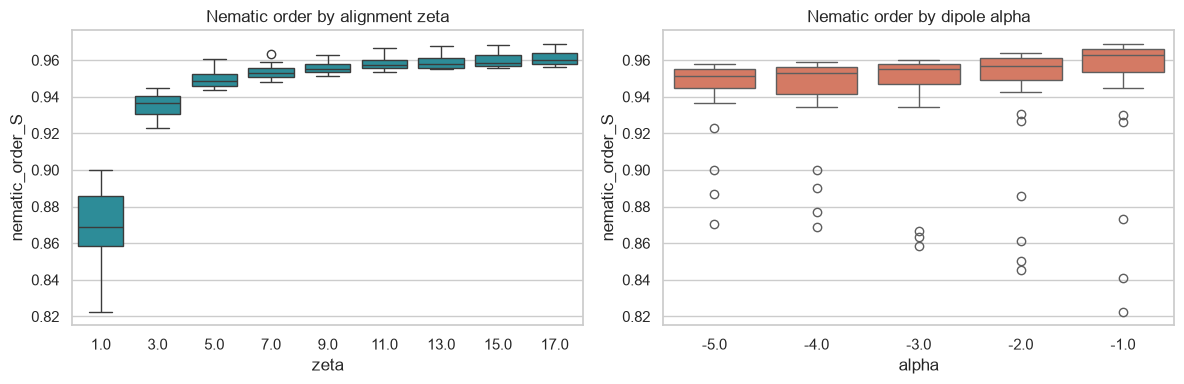

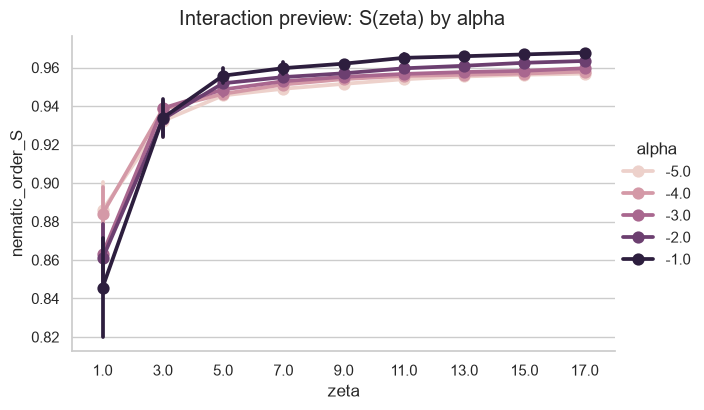

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="zeta", y="nematic_order_S", ax=axes[0], color="#1B9AAA")
axes[0].set_title("Nematic order by alignment zeta")
sns.boxplot(data=df, x="alpha", y="nematic_order_S", ax=axes[1], color="#E76F51")
axes[1].set_title("Nematic order by dipole alpha")
plt.tight_layout()
plt.show()

g = sns.catplot(
    data=df, kind="point", x="zeta", y="nematic_order_S",
    hue="alpha", errorbar="sd", height=4, aspect=1.6
)
g.fig.suptitle("Interaction preview: S(zeta) by alpha", y=1.02)
plt.show()

## 2. Two-way ANOVA — how much do initial circumstances matter?

Model: `nematic_order_S ~ C(alpha) * C(zeta)`.

We report **F**, **p**, and **partial η²** (effect size) for each term. Large partial η² for `zeta` is expected if the isotropic→nematic transition is alignment-driven.

In [4]:
tw = two_way_anova(df, "nematic_order_S", "alpha", "zeta")
display(tw["table"])
print("Verdict:", tw["verdict"])
print("N =", tw["n"])

,source,ss,df,ms,F,p,partial_eta_sq,eta_sq
0,C(alpha),0.000261,4.0,0.000065,1.458148,2.216952e-01,0.061504,0.002077
1,C(zeta),0.116436,8.0,0.014554,324.846772,2.094072e-62,0.966887,0.925626
2,C(alpha):C(zeta),0.005107,32.0,0.000160,3.561813,1.246725e-06,0.561529,0.040596
3,Residual,0.003988,89.0,0.000045,NaN,NaN,NaN,NaN


Verdict: Strong evidence for a difference (large effect)
N = 134


## 3. One-way ANOVA + Tukey HSD + pairwise t-tests

Focus on `zeta` (the strongest expected driver) and compare groups.

In [5]:
ow = one_way_anova(df, "nematic_order_S", "zeta")
print(f"F={ow['f']:.3f}, p={ow['p']:.3e}, eta^2={ow['eta_sq']:.3f}, omega^2={ow['omega_sq']:.3f}")
print("SSE (SSW) =", ow["ss_within"])
print("Verdict:", ow["verdict"])
print("\nTukey HSD (head):")
display(ow["tukey"].head(12))

tt = pairwise_ttests(df, "nematic_order_S", "zeta")
print("\nPairwise Welch t-tests (Holm-adjusted), head:")
display(tt.head(12))

F=194.914, p=9.059e-67, eta^2=0.926, omega^2=0.920
SSE (SSW) = 0.009355586349269276
Verdict: Strong evidence for a difference (large effect)

Tukey HSD (head):


,group1,group2,meandiff,p-adj,lower,upper,reject
0,1.0,11.0,0.0902,0.0000,0.0802,0.1003,True
1,1.0,13.0,0.0909,0.0000,0.0812,0.1005,True
2,1.0,15.0,0.0921,0.0000,0.0822,0.1019,True
3,1.0,17.0,0.0927,0.0000,0.0831,0.1024,True
4,1.0,3.0,0.0669,0.0000,0.0573,0.0766,True
5,1.0,5.0,0.0813,0.0000,0.0716,0.0909,True
6,1.0,7.0,0.0852,0.0000,0.0755,0.0949,True
7,1.0,9.0,0.0876,0.0000,0.0779,0.0973,True
8,11.0,13.0,0.0006,1.0000,-0.0097,0.0110,False
9,11.0,15.0,0.0019,0.9998,-0.0087,0.0124,False



Pairwise Welch t-tests (Holm-adjusted), head:


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,zeta,1.0,11.0,False,True,-17.213448,17.731585,two-sided,1.645182e-12,5.429100e-11,holm,1.422e+13,-5.434143
1,zeta,1.0,13.0,False,True,-17.442090,17.336700,two-sided,1.962876e-12,6.281202e-11,holm,9.104e+13,-5.672692
2,zeta,1.0,15.0,False,True,-17.627419,17.516904,two-sided,1.372352e-12,4.665998e-11,holm,5.577e+13,-5.648410
3,zeta,1.0,17.0,False,True,-17.775433,17.447090,two-sided,1.282856e-12,4.489997e-11,holm,1.497e+14,-5.783239
4,zeta,1.0,3.0,False,True,-12.421646,19.596291,two-sided,9.639181e-11,2.313403e-09,holm,1.759e+10,-4.069430
5,zeta,1.0,5.0,False,True,-15.527246,17.638173,two-sided,9.993397e-12,2.798151e-10,holm,4.472e+12,-5.055001
6,zeta,1.0,7.0,False,True,-16.343576,17.383835,two-sided,5.451053e-12,1.580805e-10,holm,1.672e+13,-5.316261
7,zeta,1.0,9.0,False,True,-16.862846,17.145059,two-sided,4.128745e-12,1.238624e-10,holm,3.766e+13,-5.480770
8,zeta,11.0,13.0,False,True,-0.403012,24.899246,two-sided,6.903793e-01,1.000000e+00,holm,0.376,-0.148948
9,zeta,11.0,15.0,False,True,-1.138536,24.708676,two-sided,2.658158e-01,1.000000e+00,holm,0.578,-0.425752


## 4. Assumption checks & nonparametric fallback

ANOVA assumes roughly equal variances (Levene) and normal residuals (Shapiro). If violated, use Kruskal–Wallis.

In [6]:
assumptions = assumption_checks(df, "nematic_order_S", "zeta")
display(pd.Series(assumptions))

if assumptions["recommend_nonparametric"]:
    kw = kruskal_wallis(df, "nematic_order_S", "zeta")
    print("Kruskal-Wallis H={H:.3f}, p={p:.3e}, k={k}, n={n}".format(**kw))
else:
    print("Parametric ANOVA assumptions look acceptable.")

levene_stat                10.527077
levene_p                         0.0
equal_variance                 False
shapiro_stat                0.823634
shapiro_p                        0.0
normal_residuals               False
recommend_nonparametric         True
dtype: object

Kruskal-Wallis H=102.366, p=1.401e-18, k=9, n=134


## 5. Physics-law validation

1. **Concentration conservation** — mean concentration ≈ 1 (periodic BCs, initialized at c=1).
2. **Near-incompressibility** — Stokes fluid ⇒ ∇·u ≈ 0 (we use RMS of discrete divergence).
3. **Phase transition** — nematic order should increase with alignment `zeta` (Spearman correlation).

[concentration] Mean concentration = 1.0000 (target 1.0) - PASS
[incompressibility] Mean |div u| RMS = 5.1281e-01 (relative to |u| scale: 0.652) - PASS (near-incompressible / acceptable on coarse grid)
[phase_transition] Nematic order vs zeta: Spearman rho=0.858, p=4.614e-40 - PASS (order rises with alignment)


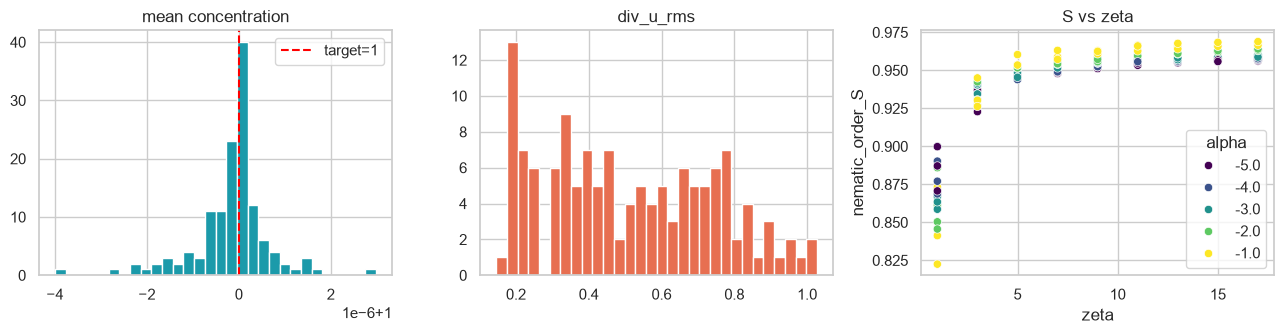

In [7]:
phys = physics_validation(df)
for name, block in phys.items():
    print(f"[{name}] {block['message']}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(df["mean_concentration"], bins=30, color="#1B9AAA", edgecolor="white")
axes[0].axvline(1.0, color="red", ls="--", label="target=1")
axes[0].set_title("mean concentration"); axes[0].legend()
axes[1].hist(df["div_u_rms"], bins=30, color="#E76F51", edgecolor="white")
axes[1].set_title("div_u_rms")
sns.scatterplot(data=df, x="zeta", y="nematic_order_S", hue="alpha", ax=axes[2], palette="viridis")
axes[2].set_title("S vs zeta")
plt.tight_layout(); plt.show()

## 6. Anomaly detection within (alpha, zeta) cells

For each parameter cell, flag trajectories whose response is an outlier (robust MAD z-score > 3.5 by default). Useful for spotting atypical random initializations or corrupted downloads.

Flagged 12 / 134 trajectories


,file,traj_idx,alpha,zeta,nematic_order_S,anomaly_score,injected_anomaly
31,active_matter_L_10.0_zeta_9.0_alpha_-5.0.hdf5,2,-5.0,9.0,0.952276,52.890600,False
112,active_matter_L_10.0_zeta_5.0_alpha_-1.0.hdf5,2,-1.0,5.0,0.960357,31.755258,False
38,active_matter_L_10.0_zeta_3.0_alpha_-4.0.hdf5,0,-4.0,3.0,0.934405,22.975200,False
90,active_matter_L_10.0_zeta_7.0_alpha_-2.0.hdf5,1,-2.0,7.0,0.956631,20.061866,False
24,active_matter_L_10.0_zeta_3.0_alpha_-5.0.hdf5,1,-5.0,3.0,0.922807,17.086432,False
34,active_matter_L_10.0_zeta_13.0_alpha_-5.0.hdf5,2,-5.0,13.0,0.954920,7.165933,False
47,active_matter_L_10.0_zeta_9.0_alpha_-4.0.hdf5,0,-4.0,9.0,0.952376,6.174926,False
53,active_matter_L_10.0_zeta_15.0_alpha_-4.0.hdf5,0,-4.0,15.0,0.957531,5.865217,False
113,active_matter_L_10.0_zeta_11.0_alpha_-1.0.hdf5,0,-1.0,11.0,0.962768,5.568265,False
73,active_matter_L_10.0_zeta_9.0_alpha_-3.0.hdf5,2,-3.0,9.0,0.955385,4.570741,False


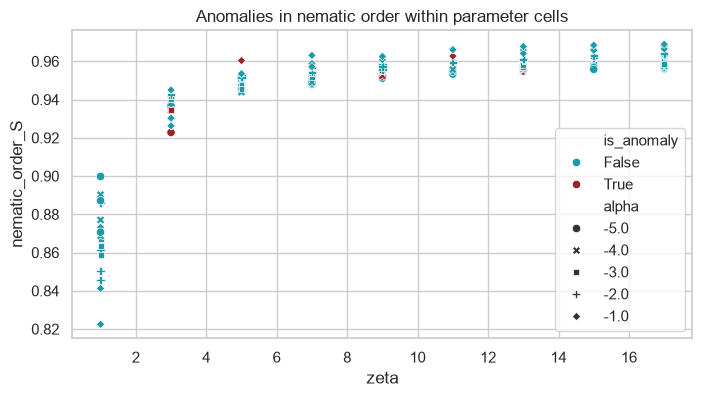

In [8]:
flagged = detect_anomalies(
    df, response="nematic_order_S", group_cols=["alpha", "zeta"], method="mad", threshold=3.5
)
n_flag = int(flagged["is_anomaly"].sum())
print(f"Flagged {n_flag} / {len(flagged)} trajectories")
cols = ["file", "traj_idx", "alpha", "zeta", "nematic_order_S", "anomaly_score"]
if "injected_anomaly" in flagged.columns:
    cols.append("injected_anomaly")
display(flagged.loc[flagged["is_anomaly"], cols].sort_values("anomaly_score", ascending=False))

plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=flagged, x="zeta", y="nematic_order_S",
    hue="is_anomaly", style="alpha", palette={False: "#1B9AAA", True: "#9B2226"}
)
plt.title("Anomalies in nematic order within parameter cells")
plt.show()

## 7. Repeat ANOVA for other responses

Compare effect sizes of `alpha` / `zeta` across several physics features.

term,C(alpha),C(alpha):C(zeta),C(zeta)
response,,,
enstrophy,0.984971,0.447760,0.619362
kinetic_energy,0.925632,0.623107,0.735084
nematic_order_S,0.061504,0.561529,0.966887
spectral_slope,0.073827,0.231724,0.464305
std_concentration,0.038157,0.135379,0.041526
time_to_steady,0.042442,0.150440,0.783970


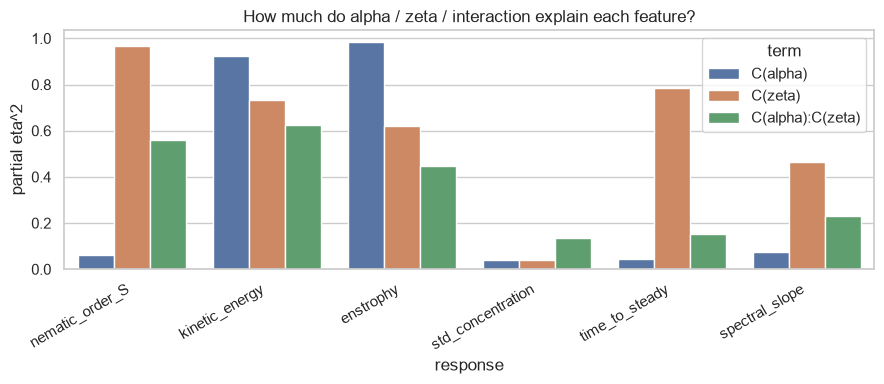

In [9]:
responses = [
    "nematic_order_S", "kinetic_energy", "enstrophy",
    "std_concentration", "time_to_steady", "spectral_slope"
]
rows = []
for resp in responses:
    tw = two_way_anova(df, resp, "alpha", "zeta")
    table = tw["table"].set_index("source")
    for src in ["C(alpha)", "C(zeta)", "C(alpha):C(zeta)"]:
        if src in table.index:
            rows.append({
                "response": resp,
                "term": src,
                "F": table.loc[src, "F"],
                "p": table.loc[src, "p"],
                "partial_eta_sq": table.loc[src, "partial_eta_sq"],
            })
effect = pd.DataFrame(rows)
display(effect.pivot(index="response", columns="term", values="partial_eta_sq"))

plt.figure(figsize=(9, 4))
sns.barplot(data=effect, x="response", y="partial_eta_sq", hue="term")
plt.xticks(rotation=30, ha="right")
plt.ylabel("partial eta^2")
plt.title("How much do alpha / zeta / interaction explain each feature?")
plt.tight_layout(); plt.show()

## Next steps

- Launch the interactive dashboard: `streamlit run app/streamlit_app.py`
- Replace the demo table with streamed Well data:
  `python -m src.extract_features --splits train --time-stride 4 --space-stride 8`
- (Optional) Restrict to a few files while testing: `--max-files 5`